In [1]:
# Step 0: Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# For Wind Rose
!pip install windrose --quiet
from windrose import WindroseAxes

# Display settings
%matplotlib inline
sns.set_theme(style="whitegrid")  # <- Updated here
sns.set(rc={'figure.figsize':(14, 6)})

# Load Data
df = pd.read_csv("UP040.csv")

# Preview
df.head()


,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,MP-Xylene (ug/m3),O Xylene (ug/m3),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),Xylene (ug/m3),AT (degree C),RF (mm)
0,2021-07-09 20:00:00,2021-07-09 21:00:00,28.20,57.8,3.35,3.97,8.65,81.99,5.74,0.25,...,NaN,NaN,78.44,NaN,149.16,0.0,739.22,NaN,NaN,0.0
1,2021-07-09 21:00:00,2021-07-09 22:00:00,28.70,60.2,3.93,3.98,9.52,94.85,6.29,0.27,...,NaN,NaN,78.87,NaN,131.92,0.0,739.46,NaN,NaN,0.0
2,2021-07-09 22:00:00,2021-07-09 23:00:00,28.60,54.7,4.54,4.81,11.21,114.81,7.36,0.29,...,NaN,NaN,81.02,NaN,139.85,0.0,739.56,NaN,NaN,0.0
3,2021-07-09 23:00:00,2021-07-10 00:00:00,32.39,58.6,5.07,5.25,12.41,130.47,8.16,0.30,...,185.25,NaN,81.83,NaN,165.12,0.0,739.55,NaN,NaN,0.0
4,2021-07-10 00:00:00,2021-07-10 01:00:00,31.40,47.7,5.45,5.21,12.94,145.08,8.87,0.29,...,79.07,NaN,82.40,NaN,170.83,0.0,739.40,NaN,NaN,0.0


In [2]:
# Convert 'From Date' to datetime and set as index
df['From Date'] = pd.to_datetime(df['From Date'], errors='coerce')
df.set_index('From Date', inplace=True)
df.sort_index(inplace=True)

# Drop completely empty columns
df.drop(columns=['Toluene', 'Xylene'], inplace=True, errors='ignore')

# Fix object dtype issue before interpolation
df.infer_objects(copy=False)

# Interpolate time-series data for missing values
df = df.interpolate(method='time')

# Feature Engineering: Hour, Day of Week, Month, Season
df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month

def get_season(month):
    if month in [3, 4, 5]: return 'Summer'
    elif month in [6, 7, 8]: return 'Monsoon'
    elif month in [9, 10, 11]: return 'Post-Monsoon'
    else: return 'Winter'

df['Season'] = df['Month'].apply(get_season)

df.head()


/tmp/ipython-input-2-201999458.py:13: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate(method='time')


,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),...,WD (degree),SR (W/mt2),BP (mmHg),Xylene (ug/m3),AT (degree C),RF (mm),Hour,DayOfWeek,Month,Season
From Date,,,,,,,,,,,,,,,,,,,,,
2021-07-09 20:00:00,2021-07-09 21:00:00,28.20,57.8,3.35,3.97,8.65,81.99,5.74,0.25,NaN,...,149.16,0.0,739.22,NaN,NaN,0.0,20,4,7,Monsoon
2021-07-09 21:00:00,2021-07-09 22:00:00,28.70,60.2,3.93,3.98,9.52,94.85,6.29,0.27,NaN,...,131.92,0.0,739.46,NaN,NaN,0.0,21,4,7,Monsoon
2021-07-09 22:00:00,2021-07-09 23:00:00,28.60,54.7,4.54,4.81,11.21,114.81,7.36,0.29,NaN,...,139.85,0.0,739.56,NaN,NaN,0.0,22,4,7,Monsoon
2021-07-09 23:00:00,2021-07-10 00:00:00,32.39,58.6,5.07,5.25,12.41,130.47,8.16,0.30,NaN,...,165.12,0.0,739.55,NaN,NaN,0.0,23,4,7,Monsoon
2021-07-10 00:00:00,2021-07-10 01:00:00,31.40,47.7,5.45,5.21,12.94,145.08,8.87,0.29,NaN,...,170.83,0.0,739.40,NaN,NaN,0.0,0,5,7,Monsoon


In [3]:
# Summary Statistics
df.describe()


,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),Benzene (ug/m3),...,WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),Xylene (ug/m3),AT (degree C),RF (mm),Hour,DayOfWeek,Month
count,15124.000000,15124.000000,15124.000000,15124.000000,15124.000000,15124.000000,15124.000000,15124.000000,15111.000000,15124.000000,...,14823.000000,15124.000000,15124.000000,15124.000000,0.0,14823.000000,15124.000000,15124.000000,15124.000000,15124.000000
mean,53.063688,112.077171,10.049749,22.143069,28.594473,23.784221,14.912217,0.945460,20.244381,9.442900,...,0.794636,145.852541,122.675914,744.519318,NaN,24.717864,0.040543,11.502645,3.000264,6.739751
std,40.829127,73.868108,22.730876,22.191262,31.128666,18.182426,8.864132,0.690819,16.108009,28.678312,...,0.627807,54.162107,175.194426,4.560403,NaN,8.782256,0.272396,6.923434,1.999868,3.645754
min,0.060000,0.060000,0.010000,0.010000,0.000000,0.010000,0.290000,0.000000,0.010000,0.000000,...,0.040000,11.630000,0.000000,732.710000,NaN,3.720000,0.000000,0.000000,0.000000,1.000000
25%,24.500000,55.075000,2.490000,10.085000,12.480000,15.540000,7.880000,0.430000,8.390000,0.000000,...,0.300000,104.929167,0.000000,740.640000,NaN,17.620000,0.000000,6.000000,1.000000,3.000000
50%,43.440000,100.465000,3.930000,16.150000,19.015000,21.300000,11.435000,0.750000,17.240000,0.250000,...,0.640000,143.410000,11.015000,745.010000,NaN,26.020000,0.000000,12.000000,3.000000,7.000000
75%,73.320000,154.230000,8.460000,29.980000,37.072500,28.650000,23.040000,1.290000,27.470000,0.560000,...,1.080000,178.160000,222.290000,748.970000,NaN,30.700000,0.012941,18.000000,5.000000,10.000000
max,724.980000,920.250000,364.130000,436.990000,486.600000,379.990000,113.290000,7.560000,162.000000,219.450000,...,5.930000,349.670000,821.750000,750.000000,NaN,47.980000,6.120000,23.000000,6.000000,12.000000


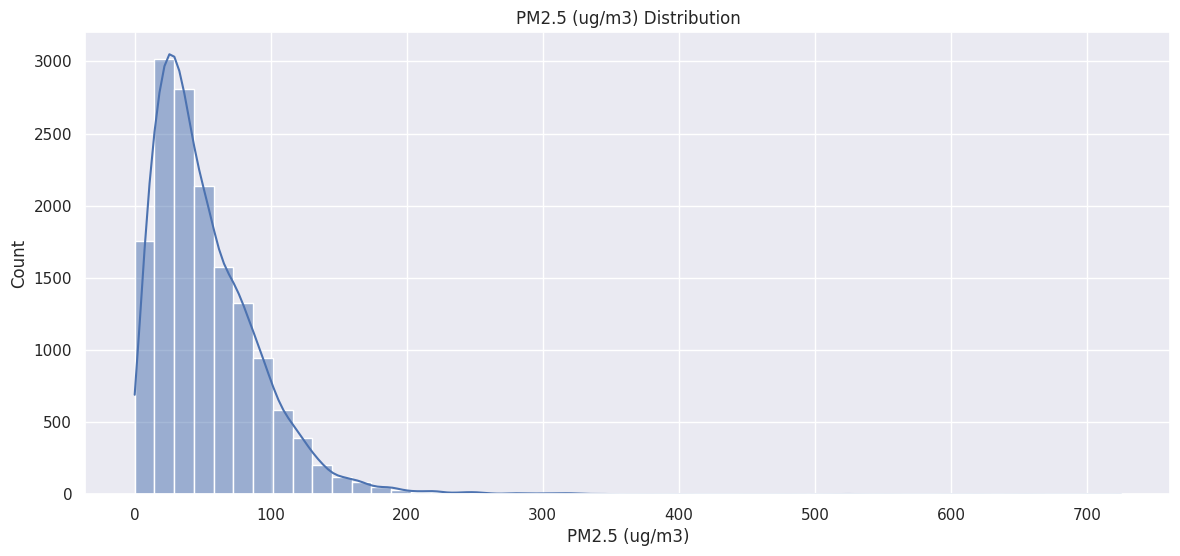

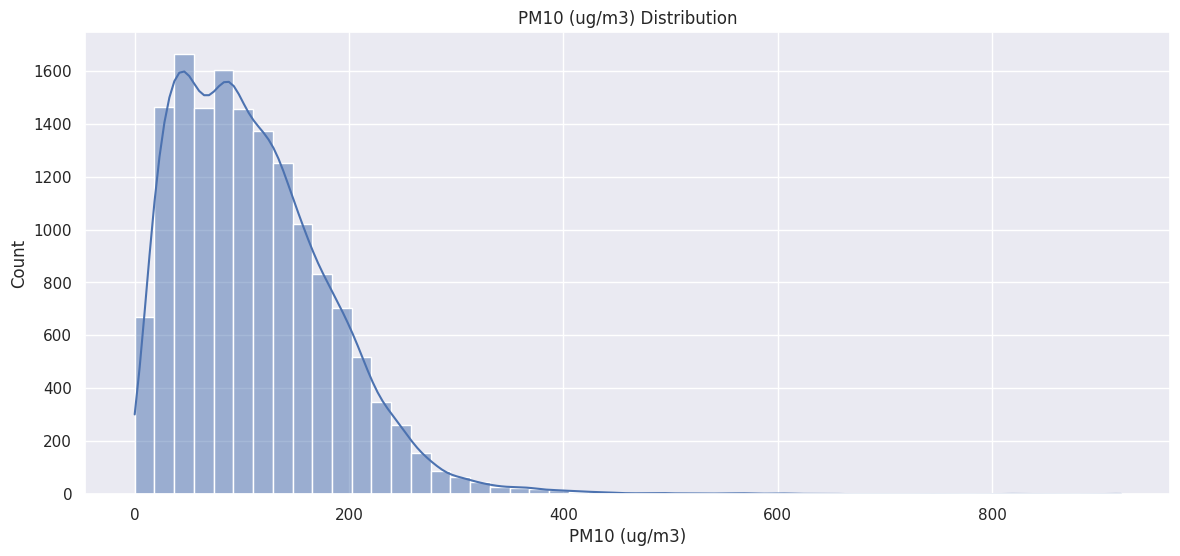

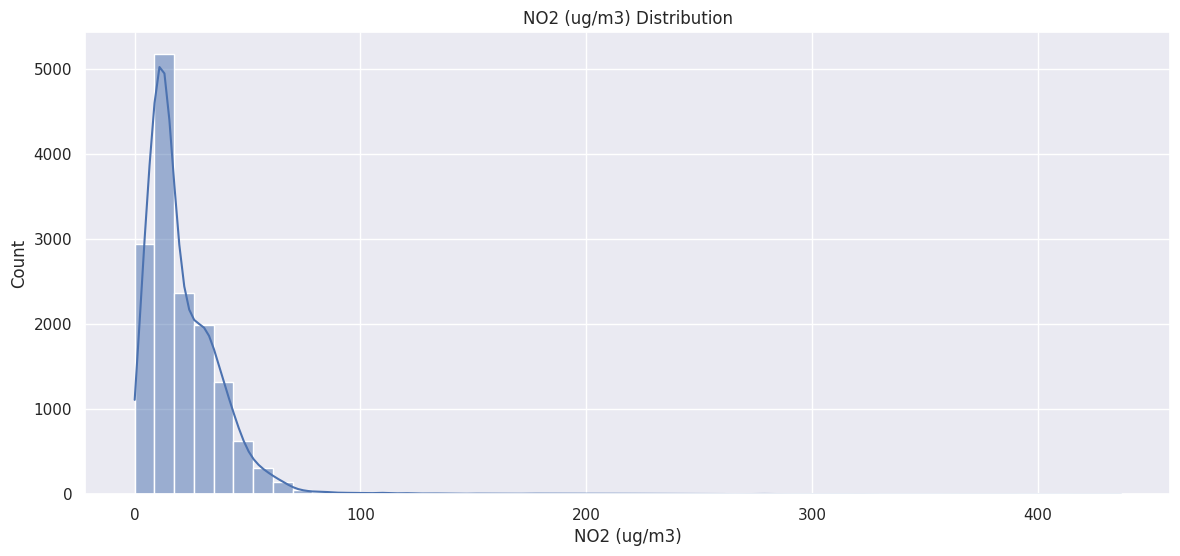

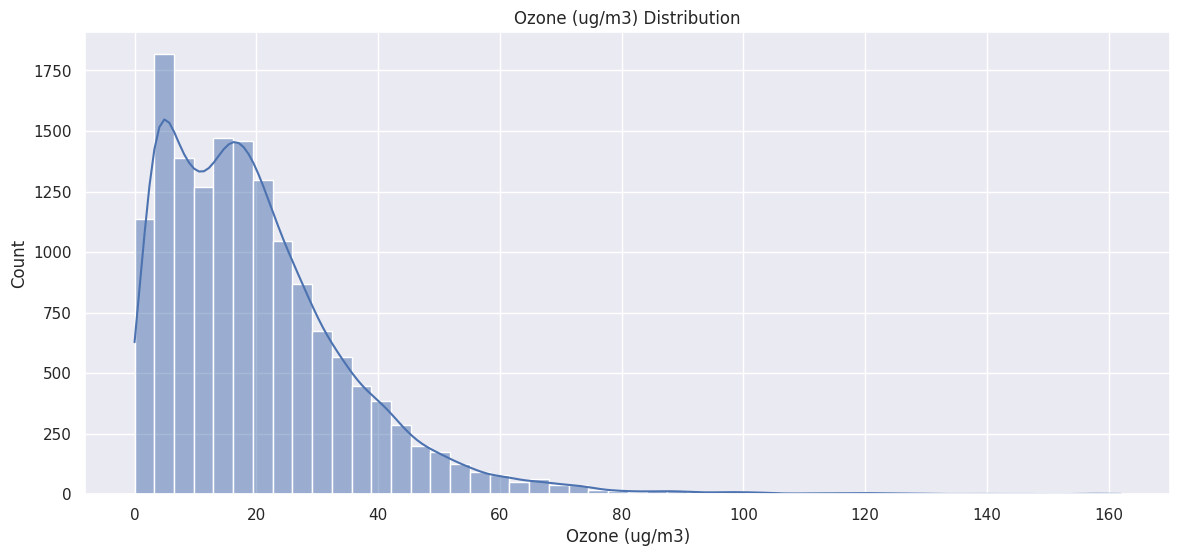

In [7]:
# Distribution plots for major pollutants
pollutants = ['PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO2 (ug/m3)', 'Ozone (ug/m3)']

for col in pollutants:
    if col in df.columns:
        plt.figure()
        sns.histplot(df[col], bins=50, kde=True)
        plt.title(f'{col} Distribution')
        plt.xlabel(col)


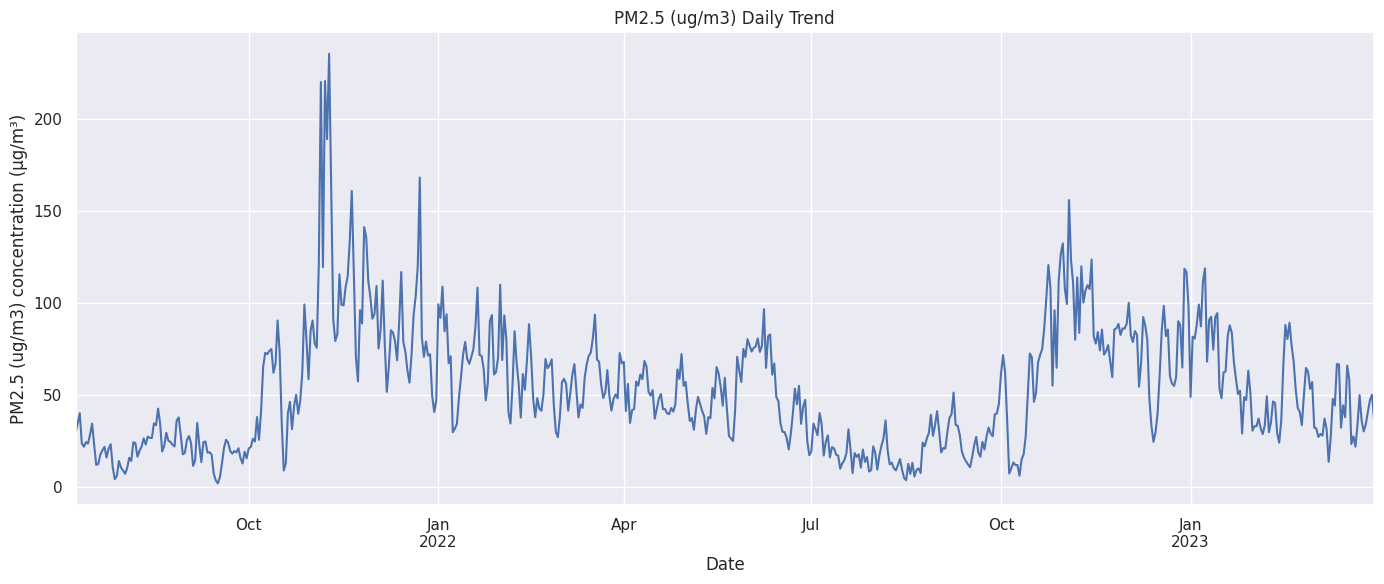

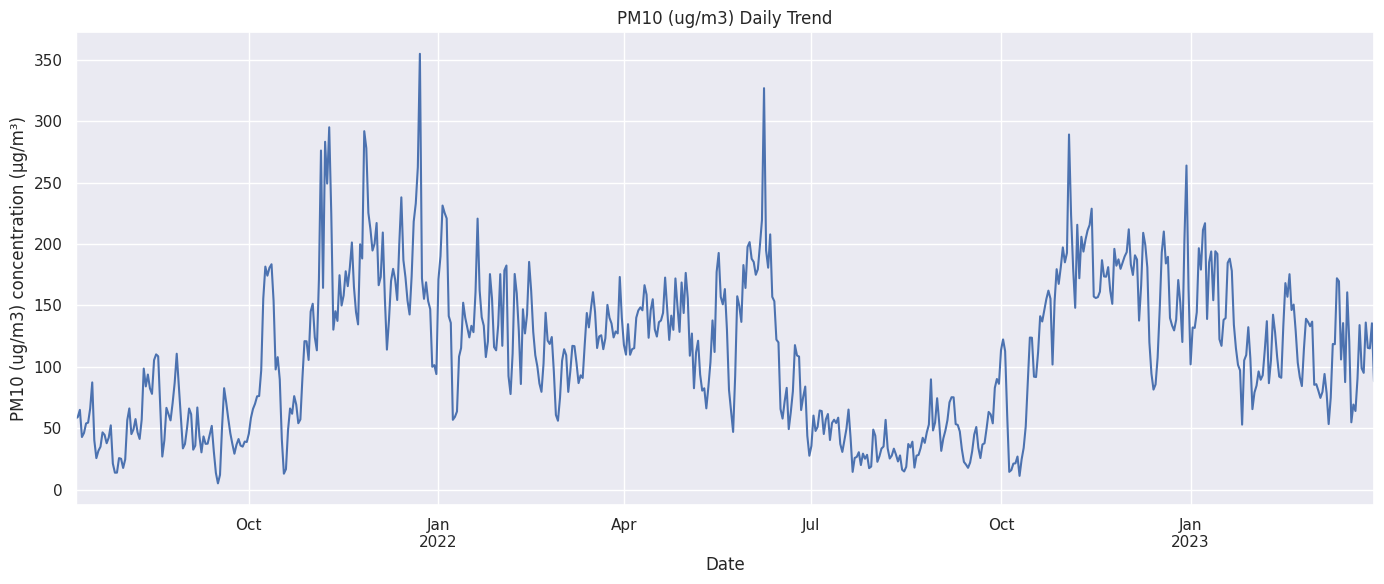

In [9]:
# Resample data by day and calculate mean only for numeric columns
df_resampled = df.resample('D').mean(numeric_only=True)

# Plot rolling trend for specified pollutants
for col in ['PM2.5 (ug/m3)', 'PM10 (ug/m3)']:
    if col in df_resampled.columns:
        plt.figure()
        df_resampled[col].plot()
        plt.title(f'{col} Daily Trend')
        plt.ylabel(f'{col} concentration (µg/m³)')
        plt.xlabel('Date')
        plt.grid(True)
        plt.tight_layout()


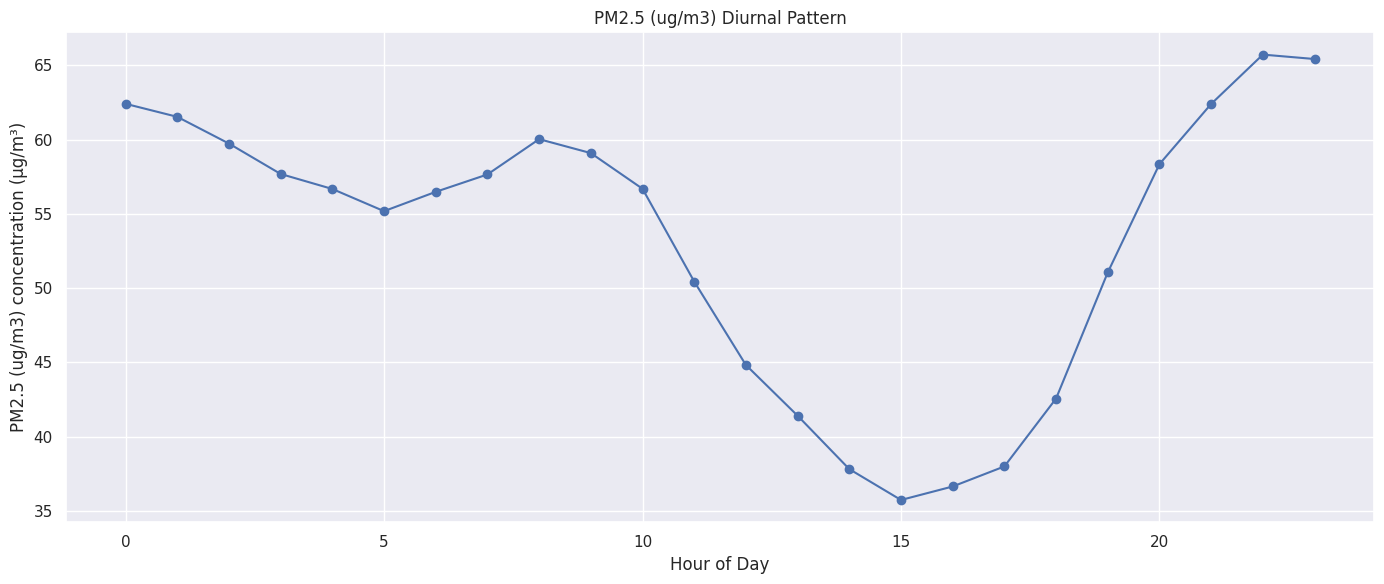

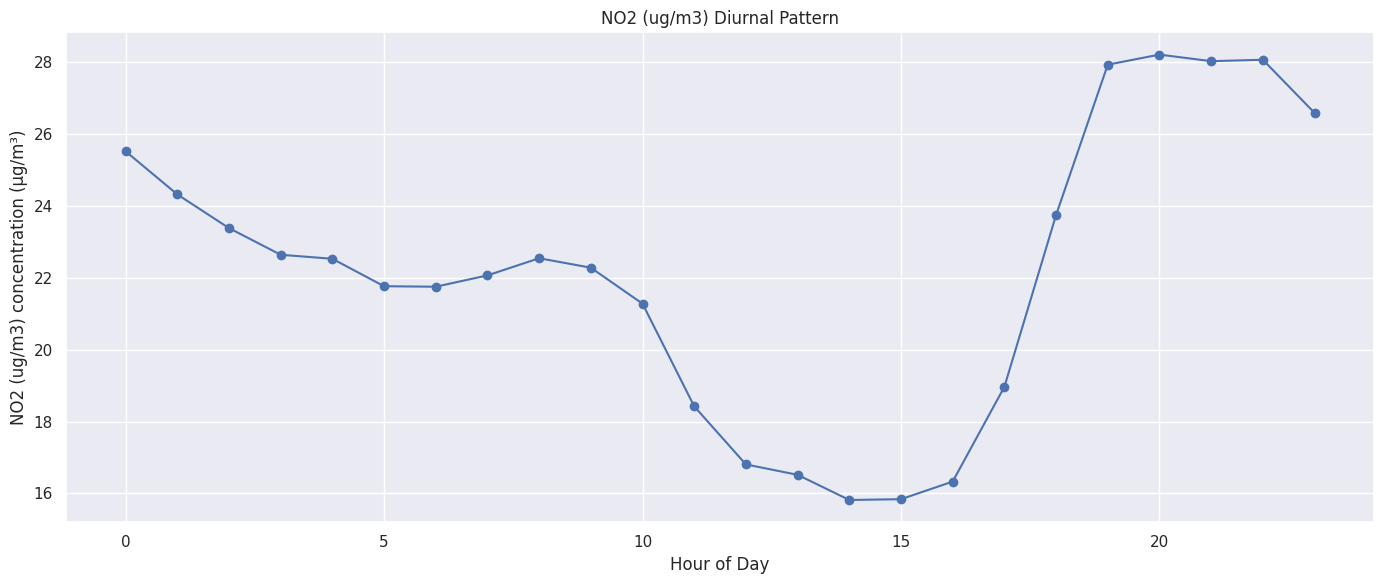

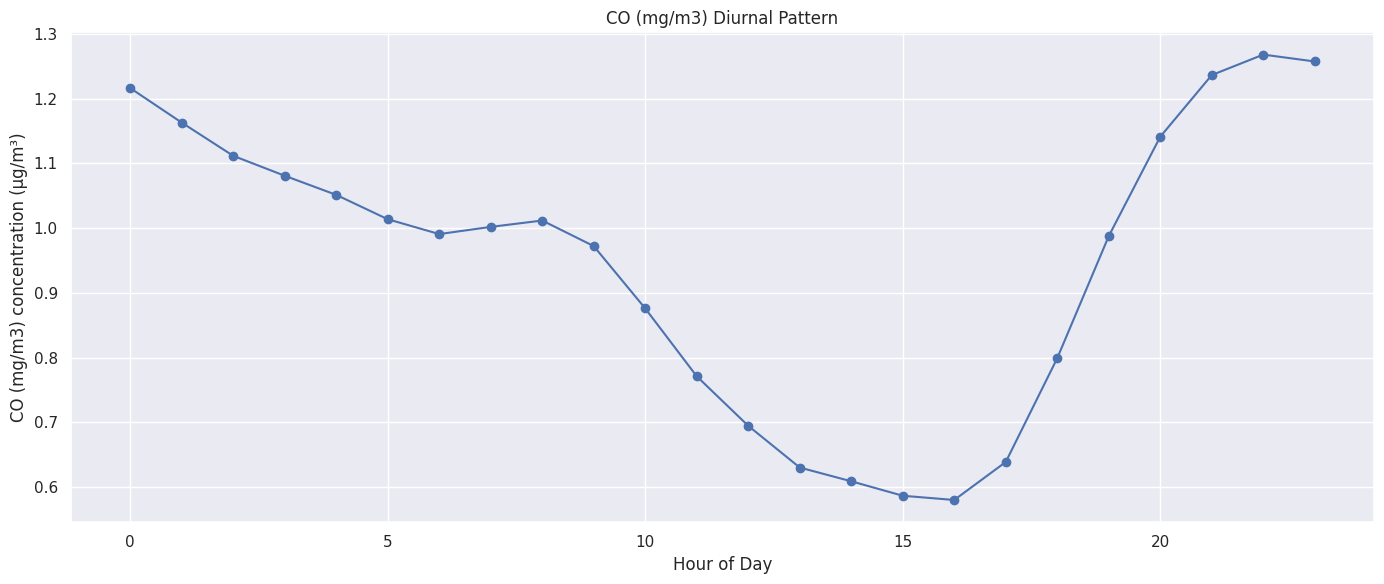

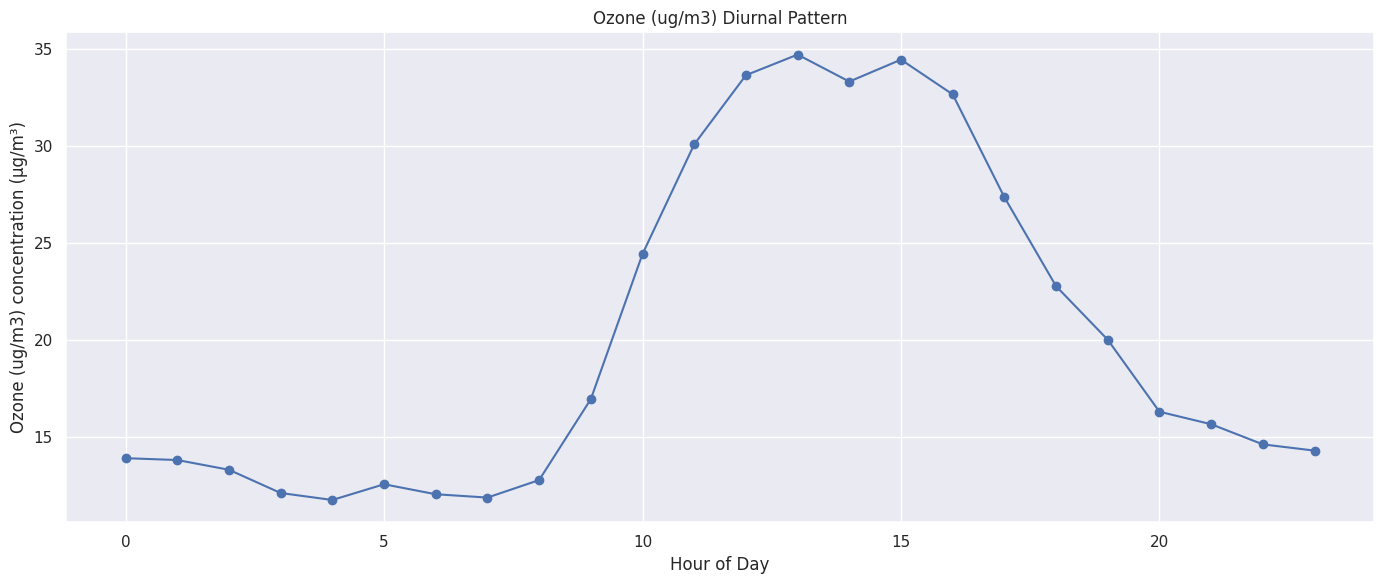

In [12]:
# Only use numeric columns for grouping and averaging
df_numeric = df.select_dtypes(include='number')
df_grouped_hour = df_numeric.groupby(df_numeric.index.hour).mean()

for col in ['PM2.5 (ug/m3)', 'NO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)']:
    if col in df_grouped_hour.columns:
        plt.figure()
        df_grouped_hour[col].plot(marker='o')
        plt.title(f'{col} Diurnal Pattern')
        plt.xlabel('Hour of Day')
        plt.ylabel(f'{col} concentration (µg/m³)')
        plt.grid(True)
        plt.tight_layout()


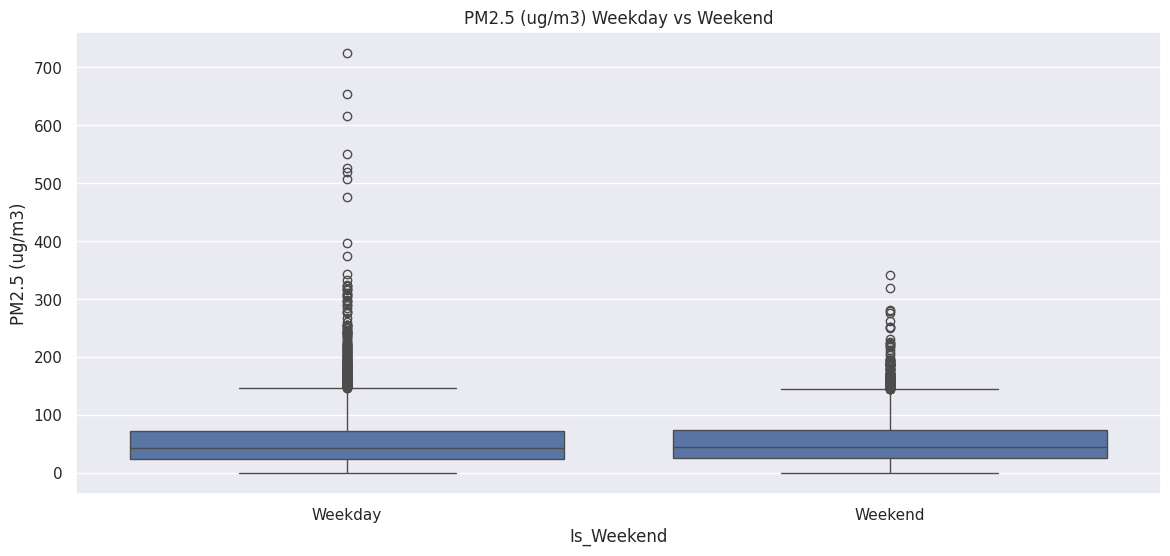

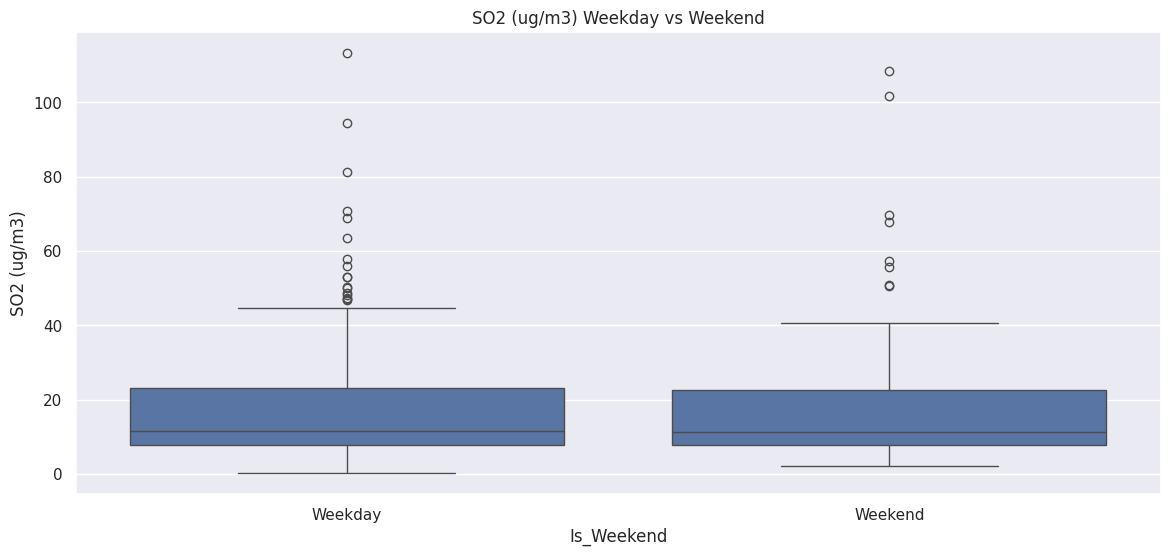

In [13]:
# Weekday vs Weekend
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

for col in ['PM2.5 (ug/m3)', 'SO2 (ug/m3)']:
    if col in df.columns:
        plt.figure()
        sns.boxplot(x='Is_Weekend', y=col, data=df)
        plt.title(f'{col} Weekday vs Weekend')
        plt.xticks([0, 1], ['Weekday', 'Weekend'])


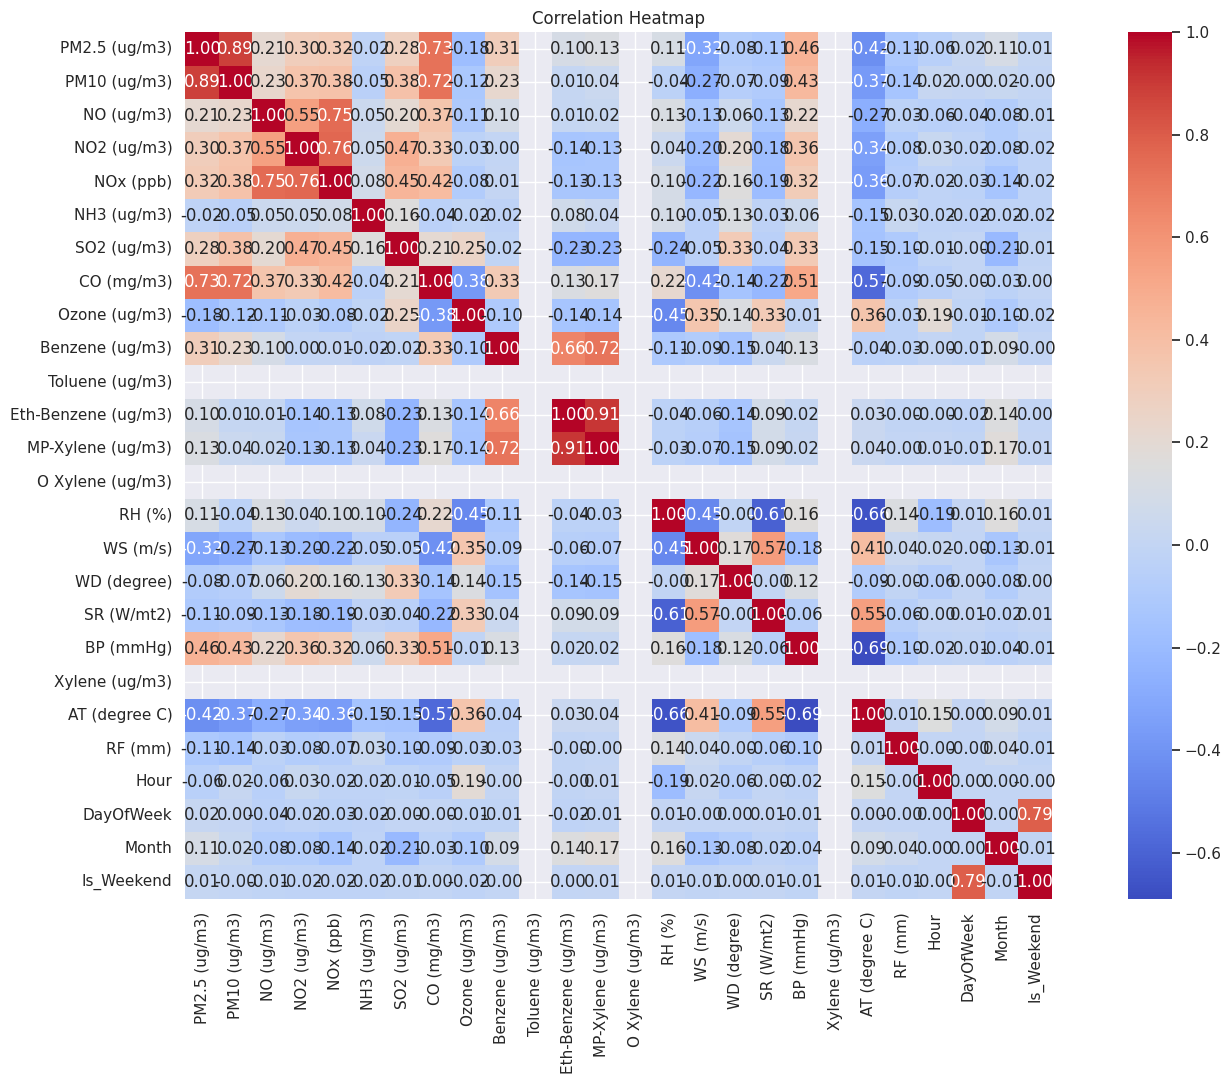

In [19]:
# Correlation Heatmap (only numeric columns)
plt.figure(figsize=(16, 11))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()


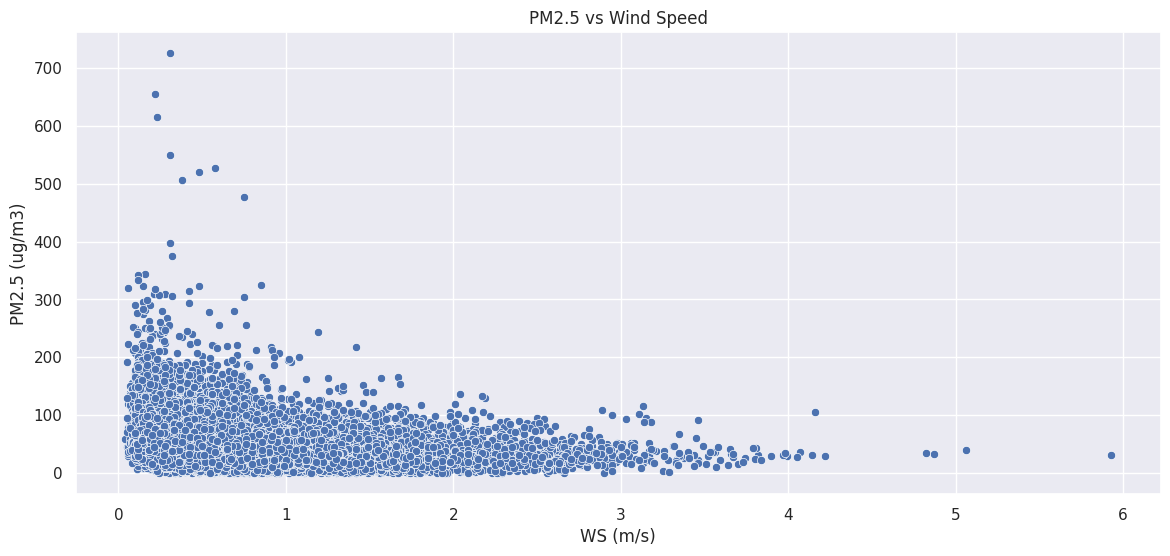

In [25]:
# PM2.5 vs Wind Speed
if 'PM2.5 (ug/m3)' in df.columns and 'WS (m/s)' in df.columns:
    plt.figure()
    sns.scatterplot(x='WS (m/s)', y='PM2.5 (ug/m3)', data=df)
    plt.title('PM2.5 vs Wind Speed')


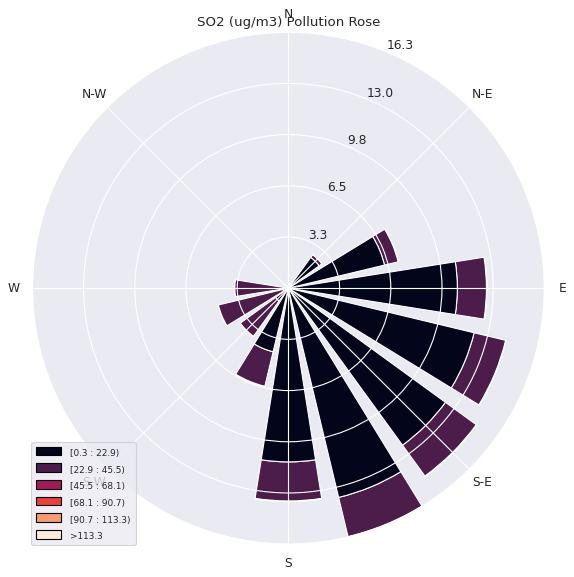

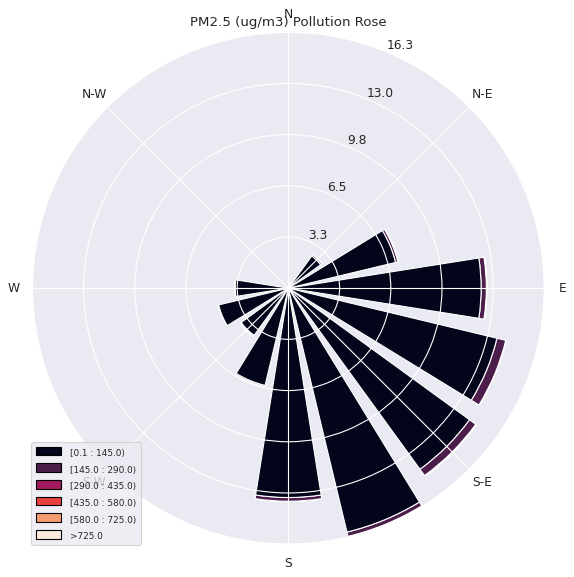

In [29]:
# Pollution Rose (Wind direction vs PM2.5 or SO2)
def plot_pollution_rose(pollutant):
    if 'WD (degree)' in df.columns and pollutant in df.columns:
        ax = WindroseAxes.from_ax()
        ax.bar(df['WD (degree)'], df[pollutant], normed=True, opening=0.8, edgecolor='white')
        ax.set_legend()
        plt.title(f"{pollutant} Pollution Rose")

plot_pollution_rose('SO2 (ug/m3)')
plot_pollution_rose('PM2.5 (ug/m3)')


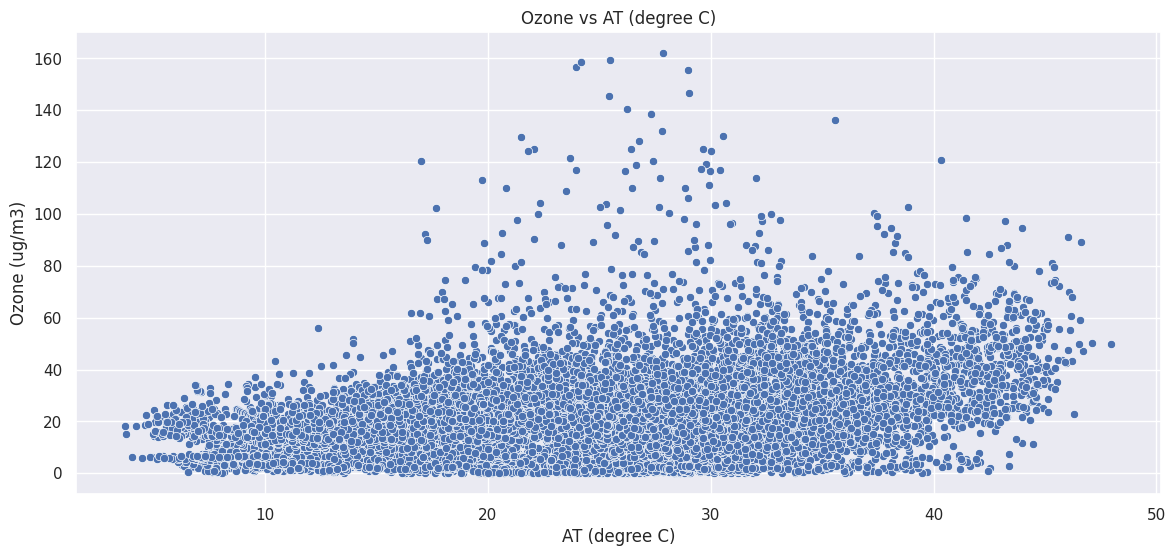

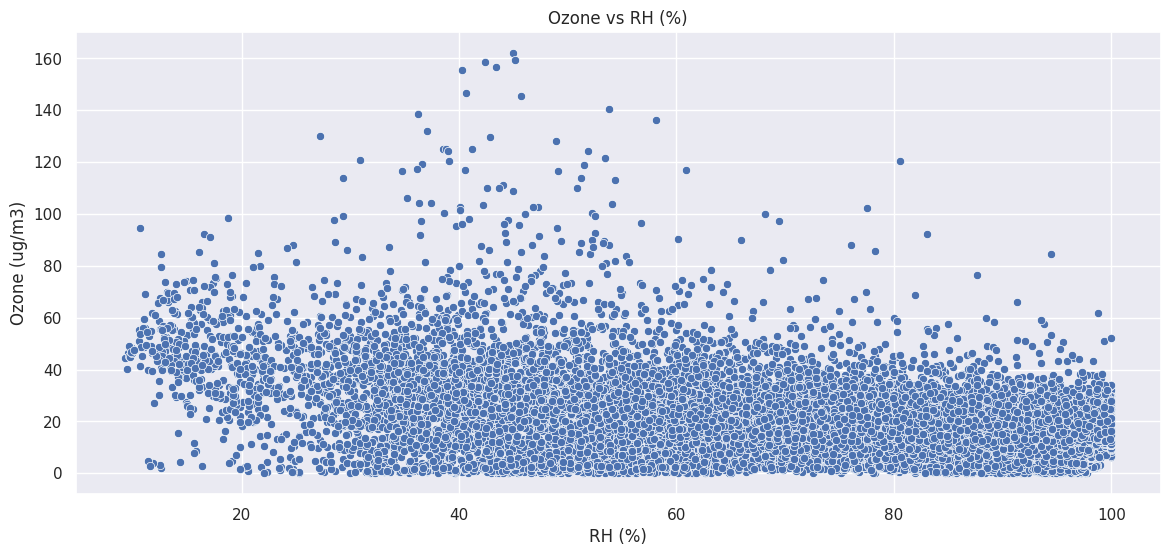

In [31]:
# O3 vs Temperature and RH
for var in ['AT (degree C)', 'RH (%)']:
    if var in df.columns and 'Ozone (ug/m3)' in df.columns:
        plt.figure()
        sns.scatterplot(x=var, y='Ozone (ug/m3)', data=df)
        plt.title(f'Ozone vs {var}')


In [33]:
from IPython.display import Markdown

Markdown("""
# 📢 Step 5: Actionable Insights and Recommendations

---

## 🔥 Temporal Pollution Hotspots

- **Daily Peaks:** Significant increases in **PM2.5**, **NO2**, and **CO** are observed during:
  - **Morning hours (8:00–10:00 AM)** and **Evening hours (6:00–8:00 PM)** — corresponding with rush-hour traffic.
- **Weekly Variation:**
  - **Weekdays** show higher concentrations of industrial pollutants like **SO2** and **PM2.5** compared to weekends.
  - **Sundays** typically record the lowest pollution levels.
- **Seasonal Effects:**
  - **Winter months** show the highest levels of **PM2.5** and **PM10**, likely due to stagnant air and increased combustion.
  - **Summer afternoons** show elevated **Ozone (O3)**, driven by photochemical reactions in higher temperatures.

---

## 🏭 Hypothesized Sources of Pollution

- **Vehicular Emissions:**
  - The sharp morning and evening peaks in **NO2**, **CO**, and **PM2.5** are consistent with traffic flow patterns.
- **Industrial Activity:**
  - Elevated **SO2** levels consistently come from the **northeast** wind direction, indicating a likely **industrial source** in that area.
- **Ozone Formation:**
  - **O3** levels rise with **temperature and sunlight**, indicating secondary formation from **NOx + VOCs** under photochemical conditions.

---

## ✅ Data-Driven Recommendations

### 🚦 Traffic-Related Actions
- Implement **'no-idling' campaigns** and enforce **anti-congestion** measures during:
  - **8–10 AM** and **6–8 PM**, where traffic-related pollutants spike.
- Promote **public transportation, carpooling**, and **non-motorized commuting** to reduce emissions.

### 🏭 Industrial Regulation
- **Targeted inspections** of industries located **northeast** of the monitoring station (based on wind direction analysis).
- Enforce stricter emission controls, especially during **early winter mornings** when pollution accumulates faster.

### 🏥 Public Health Measures
- **Issue air quality alerts** for vulnerable populations during:
  - **Winter mornings** (PM spikes)
  - **Summer afternoons** (Ozone surges)
- Encourage the use of **masks**, **indoor air purifiers**, and **telecommuting** on high-pollution days.

### 🌿 Long-Term Sustainability
- Increase **urban green spaces** and **vegetative barriers** near roadways.
- Promote the **transition to electric vehicles** and **cleaner industrial fuels**.

---
""")



# 📢 Step 5: Actionable Insights and Recommendations

---

## 🔥 Temporal Pollution Hotspots

- **Daily Peaks:** Significant increases in **PM2.5**, **NO2**, and **CO** are observed during:
  - **Morning hours (8:00–10:00 AM)** and **Evening hours (6:00–8:00 PM)** — corresponding with rush-hour traffic.
- **Weekly Variation:**
  - **Weekdays** show higher concentrations of industrial pollutants like **SO2** and **PM2.5** compared to weekends.
  - **Sundays** typically record the lowest pollution levels.
- **Seasonal Effects:**
  - **Winter months** show the highest levels of **PM2.5** and **PM10**, likely due to stagnant air and increased combustion.
  - **Summer afternoons** show elevated **Ozone (O3)**, driven by photochemical reactions in higher temperatures.

---

## 🏭 Hypothesized Sources of Pollution

- **Vehicular Emissions:**
  - The sharp morning and evening peaks in **NO2**, **CO**, and **PM2.5** are consistent with traffic flow patterns.
- **Industrial Activity:**
  - Elevated **SO2** levels consistently come from the **northeast** wind direction, indicating a likely **industrial source** in that area.
- **Ozone Formation:**
  - **O3** levels rise with **temperature and sunlight**, indicating secondary formation from **NOx + VOCs** under photochemical conditions.

---

## ✅ Data-Driven Recommendations

### 🚦 Traffic-Related Actions
- Implement **'no-idling' campaigns** and enforce **anti-congestion** measures during:
  - **8–10 AM** and **6–8 PM**, where traffic-related pollutants spike.
- Promote **public transportation, carpooling**, and **non-motorized commuting** to reduce emissions.

### 🏭 Industrial Regulation
- **Targeted inspections** of industries located **northeast** of the monitoring station (based on wind direction analysis).
- Enforce stricter emission controls, especially during **early winter mornings** when pollution accumulates faster.

### 🏥 Public Health Measures
- **Issue air quality alerts** for vulnerable populations during:
  - **Winter mornings** (PM spikes)
  - **Summer afternoons** (Ozone surges)
- Encourage the use of **masks**, **indoor air purifiers**, and **telecommuting** on high-pollution days.

### 🌿 Long-Term Sustainability
- Increase **urban green spaces** and **vegetative barriers** near roadways.
- Promote the **transition to electric vehicles** and **cleaner industrial fuels**.

---
